<a href="https://colab.research.google.com/github/Hansini23/Statistical-Learning-e23291/blob/main/ME2050_Assignment_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment:
---

## Q 1: Statistical Mechanics of the Quantum Oscillator

### 1. The Partition Function
The canonical partition function is given by:
$$Z(T) = \sum_{j=0}^{\infty} e^{-E_j / (k_B T)}$$

Given the energy eigenvalues $E_j = \hbar\omega\left(j + \frac{1}{2}\right)$, we substitute them into the sum:
$$Z(T) = \sum_{j=0}^{\infty} e^{-\frac{\hbar\omega(j + 1/2)}{k_B T}} = e^{-\frac{\hbar\omega}{2k_B T}} \sum_{j=0}^{\infty} \left(e^{-\frac{\hbar\omega}{k_B T}}\right)^j$$

This forms a geometric series of the form $\sum_{j=0}^{\infty} r^j$, where the common ratio is $r = e^{-\frac{\hbar\omega}{k_B T}}$. Because $\hbar, \omega, k_B, T > 0$, the ratio satisfies $0 < r < 1$. Thus, the series safely converges to $\frac{1}{1-r}$.

Substituting this geometric sum gives the simplified expression:
$$Z(T) = \frac{e^{-\frac{\hbar\omega}{2k_B T}}}{1 - e^{-\frac{\hbar\omega}{k_B T}}}$$

### 2. Thermodynamic Potentials

#### A. Helmholtz Free Energy, $F(T)$
Using the definition $F(T) = -k_B T \ln Z$:
$$F(T) = -k_B T \ln\left( \frac{e^{-\frac{\hbar\omega}{2k_B T}}}{1 - e^{-\frac{\hbar\omega}{k_B T}}} \right) = \frac{\hbar\omega}{2} + k_B T \ln\left(1 - e^{-\frac{\hbar\omega}{k_B T}}\right)$$

#### B. Internal Energy, $U(T)$
Rewriting $\ln Z$ in terms of $\beta = \frac{1}{k_B T}$:
$$\ln Z = -\frac{\beta\hbar\omega}{2} - \ln\left(1 - e^{-\beta\hbar\omega}\right)$$

Taking the negative partial derivative with respect to $\beta$:
$$U(T) = -\frac{\partial \ln Z}{\partial \beta} = \frac{\hbar\omega}{2} + \frac{\hbar\omega}{e^{\frac{\hbar\omega}{k_B T}} - 1}$$

### 3. Entropy
Using the thermodynamic relation $S = -\left(\frac{\partial F}{\partial T}\right)$:
$$S = -k_B \ln\left(1 - e^{-\frac{\hbar\omega}{k_B T}}\right) + \frac{\hbar\omega}{T} \frac{1}{e^{\frac{\hbar\omega}{k_B T}} - 1}$$

#### Verification: $U = F + TS$
$$F + TS = \left[\frac{\hbar\omega}{2} + k_B T \ln\left(1 - e^{-\frac{\hbar\omega}{k_B T}}\right)\right] + T \left[-k_B \ln\left(1 - e^{-\frac{\hbar\omega}{k_B T}}\right) + \frac{\hbar\omega}{T} \frac{1}{e^{\frac{\hbar\omega}{k_B T}} - 1}\right] = U(T)$$

### 4. Heat Capacity and Hyperbolic Form
The heat capacity is defined as $C_V = \frac{\partial U}{\partial T}$. Differentiating $U(T)$ gives:
$$C_V = k_B \left(\frac{\hbar\omega}{k_B T}\right)^2 \frac{e^{\frac{\hbar\omega}{k_B T}}}{\left(e^{\frac{\hbar\omega}{k_B T}} - 1\right)^2}$$

Using the identity $\sinh(x) = \frac{e^x - e^{-x}}{2}$ where $x = \frac{\hbar\omega}{2k_B T}$, we multiply the numerator and denominator by $e^{-\frac{\hbar\omega}{k_B T}}$:
$$C_V = k_B \left(\frac{\hbar\omega}{2k_B T}\right)^2 \frac{1}{\sinh^2\left(\frac{\hbar\omega}{2k_B T}\right)}$$

### 5. Asymptotic Behavior
In the high-temperature limit ($k_B T \gg \hbar\omega$), $x = \frac{\hbar\omega}{2k_B T} \to 0$. Applying the Taylor approximation $\sinh(x) \approx x$:
$$C_V \approx k_B (x)^2 \frac{1}{(x)^2} = k_B$$

**Discussion:** As $T \to \infty$, $C_V \to k_B$. This matches the classical equipartition theorem prediction perfectly, where an oscillator holds two degrees of freedom, each contributing $\frac{1}{2}k_B$.

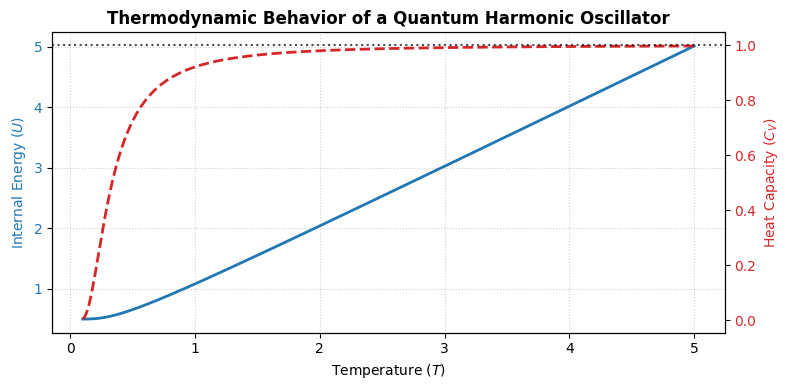

In [4]:
# Code Block 1: Quantum Harmonic Oscillator Visualization
import numpy as np
import matplotlib.pyplot as plt

hbar, omega, kb = 1.0, 1.0, 1.0
T = np.linspace(0.1, 5.0, 500)
beta = 1.0 / (kb * T)
x = (hbar * omega) / (2.0 * kb * T)

U = (hbar * omega / 2.0) + (hbar * omega) / (np.exp(beta * hbar * omega) - 1)
Cv = kb * (x**2) / (np.sinh(x)**2)

fig, ax1 = plt.subplots(figsize=(8, 4))
color = 'tab:blue'
ax1.set_xlabel('Temperature ($T$)')
ax1.set_ylabel('Internal Energy ($U$)', color=color)
ax1.plot(T, U, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Heat Capacity ($C_V$)', color=color)
ax2.plot(T, Cv, color=color, linewidth=2, linestyle='--')
ax2.axhline(kb, color='black', linestyle=':', alpha=0.7, label='Classical Limit ($k_B$)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Thermodynamic Behavior of a Quantum Harmonic Oscillator', fontweight='bold')
fig.tight_layout()
plt.show()

## Q 2: Maximum Entropy Distribution under Mean and Variance Constraints

We seek a continuous probability density function $f(x)$ for a random variable $X \in (-\infty, \infty)$ that maximizes the differential entropy $H(X) = - \int_{-\infty}^{\infty} f(x) \ln f(x) \, dx$ subject to:
1. $\int_{-\infty}^{\infty} f(x) \, dx = 1$
2. $\int_{-\infty}^{\infty} x f(x) \, dx = \mu$
3. $\int_{-\infty}^{\infty} (x-\mu)^2 f(x) \, dx = \sigma^2$

### 1. Formulating the Lagrangian
Using Lagrange multipliers $\lambda_0, \lambda_1, \lambda_2$:
$$L[f] = -\int_{-\infty}^{\infty} f(x) \ln f(x) \, dx - \lambda_0 \left( \int_{-\infty}^{\infty} f(x) \, dx - 1 \right) - \lambda_1 \left( \int_{-\infty}^{\infty} x f(x) \, dx - \mu \right) - \lambda_2 \left( \int_{-\infty}^{\infty} (x-\mu)^2 f(x) \, dx - \sigma^2 \right)$$

### 2. Extremizing the Functional
Taking the functional derivative with respect to $f(x)$ and setting it to zero:
$$\frac{\delta L}{\delta f(x)} = -1 - \ln f(x) - \lambda_0 - \lambda_1 x - \lambda_2(x-\mu)^2 = 0$$
$$f(x) = \exp\left(-(1 + \lambda_0) - \lambda_1 x - \lambda_2(x-\mu)^2\right)$$

### 3. Solving for the Lagrange Multipliers
To maintain the target mean symmetry strictly centered at $x = \mu$, the coefficient $\lambda_1$ must equal $0$. Let $C = e^{-(1+\lambda_0)}$:
$$f(x) = C \exp\left(-\lambda_2(x-\mu)^2\right)$$

Evaluating $C$ and $\lambda_2$ using standard definite Gaussian integrals:
* **Normalization:** $\int_{-\infty}^{\infty} f(x)dx = 1 \implies C = \sqrt{\frac{\lambda_2}{\pi}}$
* **Variance:** $\int_{-\infty}^{\infty} (x-\mu)^2 f(x) dx = \sigma^2 \implies \frac{1}{2\lambda_2} = \sigma^2 \implies \lambda_2 = \frac{1}{2\sigma^2}$

### 4. Final Substitution
Substituting $\lambda_2$ back into $C$ gives $C = \frac{1}{\sqrt{2\pi\sigma^2}}$. Thus, the definitive distribution is:
$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right) \implies X \sim \mathcal{N}(\mu, \sigma^2)$$

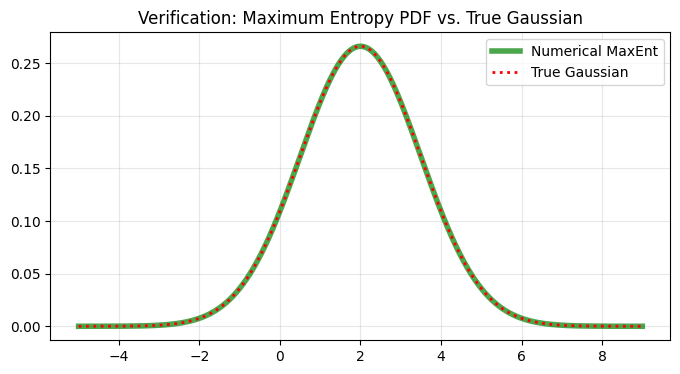

In [5]:
# Code Block 2: MaxEnt Gaussian Verification
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

mu, sigma = 2.0, 1.5
variance = sigma**2
x_domain = np.linspace(-5, 9, 1000)
dx = x_domain[1] - x_domain[0]

def dual_objective(params):
    l1, l2 = params
    exponent = -l1 * x_domain - l2 * (x_domain - mu)**2
    Z = np.sum(np.exp(exponent)) * dx
    return np.log(Z) + l1 * mu + l2 * variance

result = minimize(dual_objective, [0.0, 0.5], method='L-BFGS-B')
l1_opt, l2_opt = result.x

max_ent_pdf = np.exp(-l1_opt * x_domain - l2_opt * (x_domain - mu)**2)
max_ent_pdf /= (np.sum(max_ent_pdf) * dx)
true_gaussian = (1.0 / np.sqrt(2.0 * np.pi * variance)) * np.exp(-(x_domain - mu)**2 / (2.0 * variance))

plt.figure(figsize=(8, 4))
plt.plot(x_domain, max_ent_pdf, label='Numerical MaxEnt', color='green', linewidth=4, alpha=0.7)
plt.plot(x_domain, true_gaussian, label='True Gaussian', color='red', linestyle=':', linewidth=2)
plt.title('Verification: Maximum Entropy PDF vs. True Gaussian')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Q 3: Multiclass Logistic Regression - Automatic Classification of Emails

### 1. Problem Formulation and Constraints
We have an email classification system with a state vector $\mathbf{x} = (x_1, x_2, x_3)^T$ and routing targets $Y \in \{0, 1\}$. The historical scenario distributions $P(\mathbf{x})$ are given.

The audit joint expectations expand using the law of total probability:
$$\mathbb{E}[x_i \cdot \mathbb{I}(Y=1)] = \sum_{\mathbf{x}} P(\mathbf{x}) \cdot x_i \cdot P(Y=1 \mid \mathbf{x})$$

* **Constraint 1 (Financial):** $0.40 P(Y=1 \mid \mathbf{x}_A) + 0.05 P(Y=1 \mid \mathbf{x}_E) = 0.05$
* **Constraint 2 (Access):** $0.25 P(Y=1 \mid \mathbf{x}_B) + 0.15 P(Y=1 \mid \mathbf{x}_D) + 0.05 P(Y=1 \mid \mathbf{x}_E) = 0.15$
* **Constraint 3 (Technical):** $0.05 P(Y=1 \mid \mathbf{x}_C) + 0.15 P(Y=1 \mid \mathbf{x}_D) = 0.16$

### 2. Checking System Feasibility and Bounds
From **Constraint 3**, given that probabilities are bounded ($0 \le P \le 1$):
If $P(Y=1 \mid \mathbf{x}_D) = 1.0$:
$$0.05 P(Y=1 \mid \mathbf{x}_C) + 0.15(1.0) = 0.16 \implies P(Y=1 \mid \mathbf{x}_C) = 0.20$$

Substituting $P(Y=1 \mid \mathbf{x}_D) = 1.0$ into **Constraint 2**:
$$0.25 P(Y=1 \mid \mathbf{x}_B) + 0.15(1.0) + 0.05 P(Y=1 \mid \mathbf{x}_E) = 0.15 \implies 0.25 P(Y=1 \mid \mathbf{x}_B) + 0.05 P(Y=1 \mid \mathbf{x}_E) = 0$$
Because probabilities cannot be negative, this explicitly enforces:
$$P(Y=1 \mid \mathbf{x}_B) = 0.0, \quad P(Y=1 \mid \mathbf{x}_E) = 0.0$$

Substituting $P(Y=1 \mid \mathbf{x}_E) = 0.0$ into **Constraint 1**:
$$0.40 P(Y=1 \mid \mathbf{x}_A) + 0.05(0.0) = 0.05 \implies P(Y=1 \mid \mathbf{x}_A) = \frac{0.05}{0.40} = 0.125$$

### 3. Summary Operational Policy Matrix

| Scenario | State Vector $\mathbf{x}^T$ | Marginal $P(\mathbf{x})$ | Technical $P(Y=1 \mid \mathbf{x})$ | Finance $P(Y=0 \mid \mathbf{x})$ |
| :--- | :--- | :--- | :--- | :--- |
| **A (Pure Financial)** | $(1, 0, 0)$ | $0.40$ | $0.125$ | $0.875$ |
| **B (Pure Access)** | $(0, 1, 0)$ | $0.25$ | $0.000$ | $1.000$ |
| **C (Pure Technical)** | $(0, 0, 1)$ | $0.05$ | $0.200$ | $0.800$ |
| **D (Access Tech)** | $(0, 1, 1)$ | $0.15$ | $1.000$ | $0.000$ |
| **E (Billing Access)** | $(1, 1, 0)$ | $0.05$ | $0.000$ | $1.000$ |

In [6]:
# Code Block 3: Verification of Logistic Regression Constraints
import numpy as np

# Empirical Routing Conditional Probabilities Derived
P_Y1_A = 0.125
P_Y1_B = 0.0
P_Y1_C = 0.20
P_Y1_D = 1.0
P_Y1_E = 0.0

# Marginal Probabilities of Scenarios
P_A, P_B, P_C, P_D, P_E = 0.40, 0.25, 0.05, 0.15, 0.05

# Verification calculations
E_x1_Y1 = (P_A * 1 * P_Y1_A) + (P_E * 1 * P_Y1_E)
E_x2_Y1 = (P_B * 1 * P_Y1_B) + (P_D * 1 * P_Y1_D) + (P_E * 1 * P_Y1_E)
E_x3_Y1 = (P_C * 1 * P_Y1_C) + (P_D * 1 * P_Y1_D)

print(f"Verified Constraint 1 (Expected Target 0.05): {E_x1_Y1:.2f}")
print(f"Verified Constraint 2 (Expected Target 0.15): {E_x2_Y1:.2f}")
print(f"Verified Constraint 3 (Expected Target 0.16): {E_x3_Y1:.2f}")

Verified Constraint 1 (Expected Target 0.05): 0.05
Verified Constraint 2 (Expected Target 0.15): 0.15
Verified Constraint 3 (Expected Target 0.16): 0.16


## Q 4: Asset Pricing and Portfolio Optimization

We maximize the differential entropy $H(p) = -\int_{0}^{\infty} p(S_T) \ln p(S_T) \, dS_T$ under four constraints:
1. $\int_{0}^{\infty} p(S_T) \, dS_T = 1$
2. $\int_{0}^{\infty} S_T \, p(S_T) \, dS_T = \mathbb{E}[S_T] = 102$
3. $\int_{0}^{\infty} S_T^2 \, p(S_T) \, dS_T = \mathbb{E}[S_T^2] = 10,600$
4. $\int_{0}^{\infty} \ln(S_T) \, p(S_T) \, dS_T = \mathbb{E}[\ln(S_T)] = 4.60$

### 1. Formulating the Lagrangian and Finding its Extremum
$$L[p] = -\int_{0}^{\infty} p(S_T) \ln p(S_T) \, dS_T - \lambda_0 \left( \int_{0}^{\infty} p(S_T) \, dS_T - 1 \right) - \lambda_1 \left( \int_{0}^{\infty} S_T \, p(S_T) \, dS_T - 102 \right) - \lambda_2 \left( \int_{0}^{\infty} S_T^2 \, p(S_T) \, dS_T - 10,600 \right) - \lambda_3 \left( \int_{0}^{\infty} \ln(S_T) \, p(S_T) \, dS_T - 4.60 \right)$$

Taking the functional derivative and setting it to zero:
$$\frac{\delta L}{\delta p(S_T)} = -1 - \ln p(S_T) - \lambda_0 - \lambda_1 S_T - \lambda_2 S_T^2 - \lambda_3 \ln(S_T) = 0$$

Isolating $p(S_T)$ gives the generalized exponential distribution shape:
$$p(S_T) = \frac{1}{Z} S_T^{-\lambda_3} \exp\left(-\lambda_1 S_T - \lambda_2 S_T^2\right)$$

### 2. Numerical Optimization Model
Since this configuration cannot be integrated analytically in closed form, the optimal values for the parameters $(\lambda_1, \lambda_2, \lambda_3)$ are solved numerically by minimizing the convex dual objective function:
$$\Gamma(\lambda_1, \lambda_2, \lambda_3) = \ln \int_{0}^{\infty} S_T^{-\lambda_3} \exp\left(-\lambda_1 S_T - \lambda_2 S_T^2\right) dS_T + 102\lambda_1 + 10,600\lambda_2 + 4.60\lambda_3$$

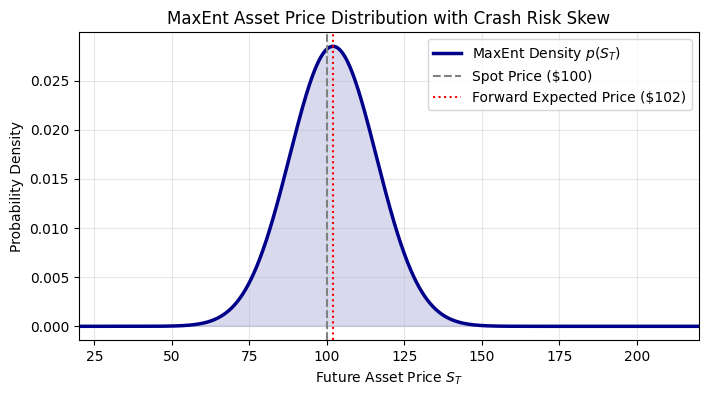

In [7]:
# Code Block 4: Asset Pricing Numerical Optimization and Curve Generation
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.integrate import simpson

E_ST, E_ST2, E_lnST = 102.0, 10600.0, 4.60
St_domain = np.linspace(1.0, 300.0, 2000)

def asset_dual_objective(lambdas):
    l1, l2, l3 = lambdas
    exponent = -l1 * St_domain - l2 * (St_domain**2) - l3 * np.log(St_domain)
    max_exp = np.max(exponent)

    integrand = np.exp(exponent - max_exp)
    Z_scaled = simpson(integrand, x=St_domain)
    return np.log(Z_scaled) + max_exp + l1 * E_ST + l2 * E_ST2 + l3 * E_lnST

res = minimize(asset_dual_objective, [0.01, 0.0001, 0.1], method='L-BFGS-B')
l1_opt, l2_opt, l3_opt = res.x

final_exponent = -l1_opt * St_domain - l2_opt * (St_domain**2) - l3_opt * np.log(St_domain)
unnorm_pdf = np.exp(final_exponent - np.max(final_exponent))
max_ent_asset_pdf = unnorm_pdf / simpson(unnorm_pdf, x=St_domain)

plt.figure(figsize=(8, 4))
plt.plot(St_domain, max_ent_asset_pdf, color='darkblue', linewidth=2.5, label='MaxEnt Density $p(S_T)$')
plt.fill_between(St_domain, max_ent_asset_pdf, alpha=0.15, color='darkblue')
plt.axvline(100, color='gray', linestyle='--', label='Spot Price ($100)')
plt.axvline(E_ST, color='red', linestyle=':', label='Forward Expected Price ($102)')
plt.title('MaxEnt Asset Price Distribution with Crash Risk Skew')
plt.xlabel('Future Asset Price $S_T$')
plt.ylabel('Probability Density')
plt.xlim(20, 220)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()